In [135]:
import sys
!{sys.executable} -m pip install pandas openpyxl matplotlib seaborn python-dotenv google-generativeai


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All imports working ✓")

All imports working ✓


In [137]:
data = {
    'Company': ['Zomato','Zomato','Zomato','Zomato','Zomato',
                'Nykaa','Nykaa','Nykaa','Nykaa','Nykaa',
                'Paytm','Paytm','Paytm','Paytm','Paytm'],
    'Year':    ['FY21','FY22','FY23','FY24','FY25',
                'FY21','FY22','FY23','FY24','FY25',
                'FY21','FY22','FY23','FY24','FY25'],
    'Sales':   [1994,4192,7079,12114,17003,
                2453,3774,5144,6386,7754,
                2802,4974,7990,9978,10483],
    'Expenses':[3403,6499,8693,12294,15337,
                2369,3726,4940,6116,7248,
                4826,7286,9609,11115,10298],
    'Operating Profit':[-1409,-2307,-1614,-180,1666,
                        84,48,204,270,506,
                        -2024,-2312,-1619,-1137,185],
    'Net profit':[-816,-1222,-971,351,527,
                  62,-20,9,40,26,
                  -1701,-2396,-1776,-1422,1422],
    'OPM':[-71,-55,-23,-1,10,
           3,1,4,4,7,
           -72,-46,-20,-11,2]
}

df_all = pd.DataFrame(data)
print("✓ Data loaded")
print("Rows:", len(df_all))
print("Companies:", df_all['Company'].unique().tolist())
print(df_all.head(6))

✓ Data loaded
Rows: 15
Companies: ['Zomato', 'Nykaa', 'Paytm']
  Company  Year  Sales  Expenses  Operating Profit  Net profit  OPM
0  Zomato  FY21   1994      3403             -1409        -816  -71
1  Zomato  FY22   4192      6499             -2307       -1222  -55
2  Zomato  FY23   7079      8693             -1614        -971  -23
3  Zomato  FY24  12114     12294              -180         351   -1
4  Zomato  FY25  17003     15337              1666         527   10
5   Nykaa  FY21   2453      2369                84          62    3


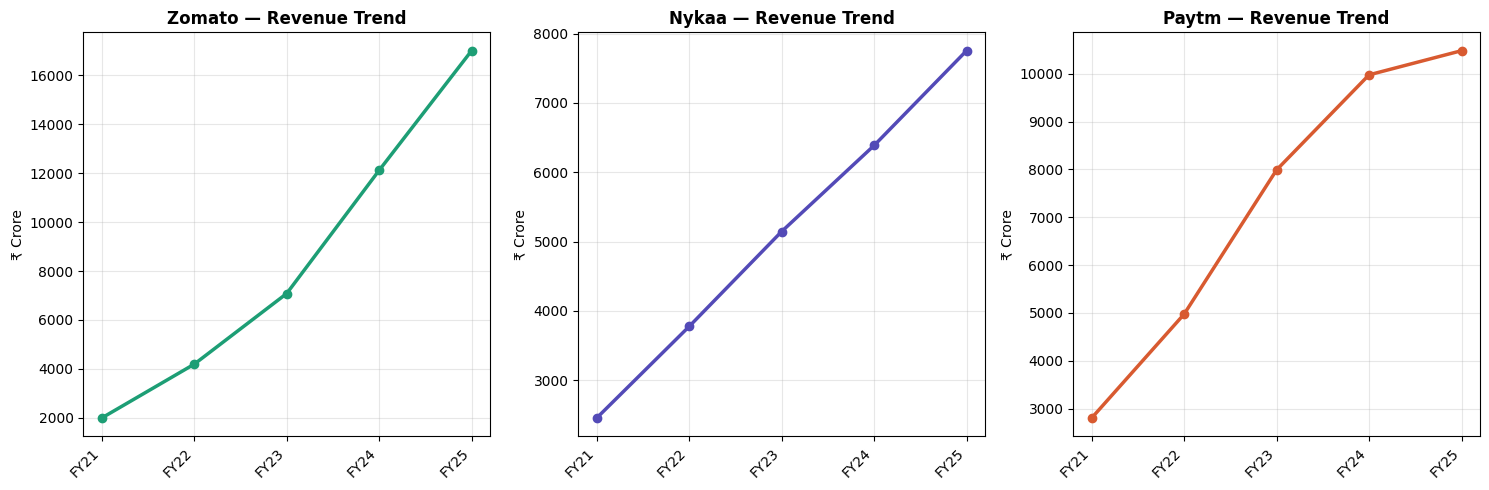

✓ revenue_trend.png saved


In [138]:
companies = ['Zomato', 'Nykaa', 'Paytm']
colors = ['#1D9E75', '#534AB7', '#D85A30']
years = ['FY21','FY22','FY23','FY24','FY25']
x = list(range(5))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (company, color) in enumerate(zip(companies, colors)):
    data = df_all[df_all['Company'] == company].copy()
    sales = data['Sales'].values
    axes[i].plot(x, sales, marker='o', color=color, linewidth=2.5, markersize=6)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(years, rotation=45, ha='right')
    axes[i].set_title(f'{company} — Revenue Trend', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('₹ Crore')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ revenue_trend.png saved")

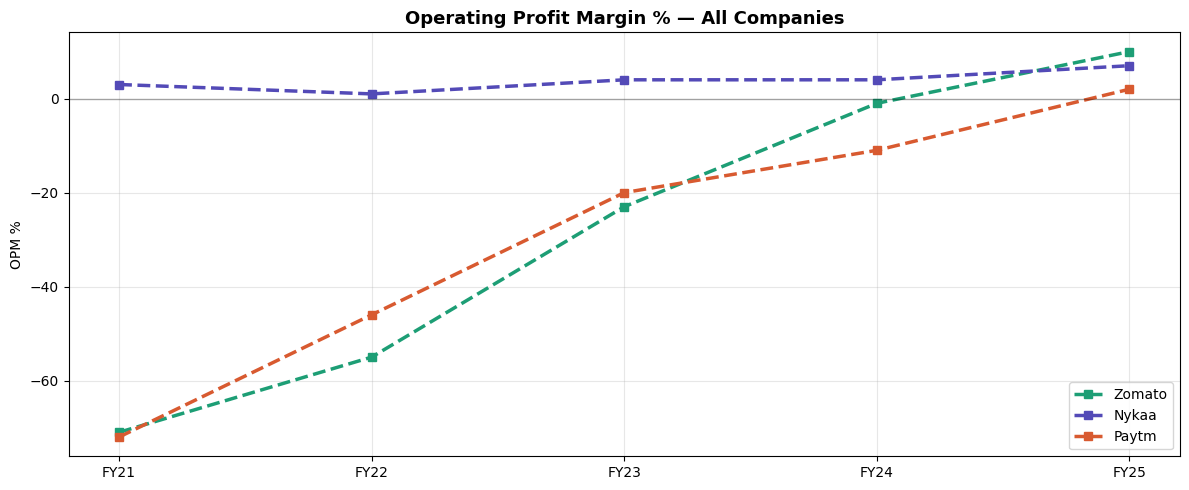

✓ opm_comparison.png saved


In [139]:
fig, ax = plt.subplots(figsize=(12, 5))

for company, color in zip(companies, colors):
    data = df_all[df_all['Company'] == company].copy()
    ax.plot(x, data['OPM'].values,
            marker='s', label=company, color=color,
            linewidth=2.5, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
ax.set_title('Operating Profit Margin % — All Companies',
             fontweight='bold', fontsize=13)
ax.set_ylabel('OPM %')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/opm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ opm_comparison.png saved")

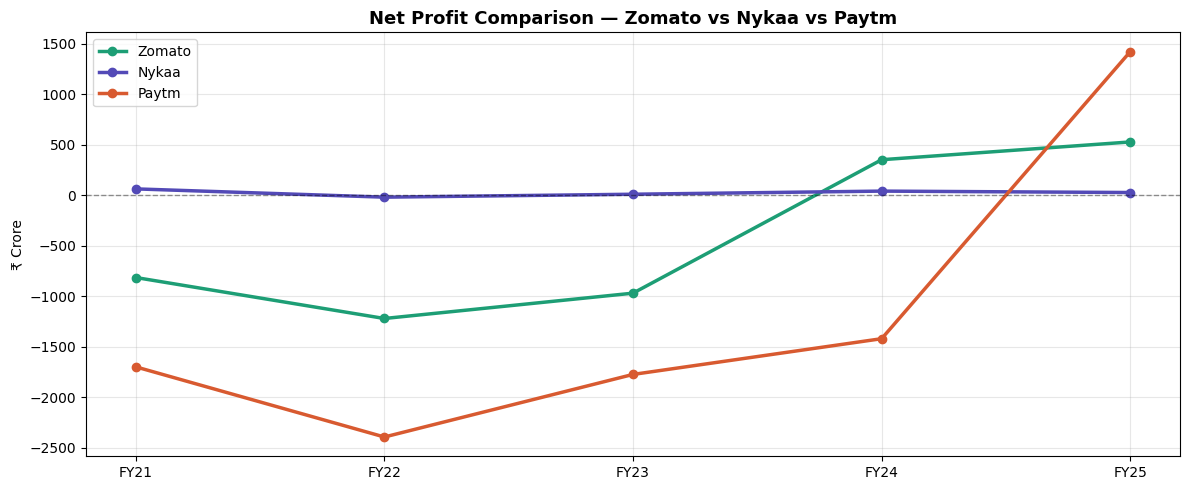

✓ net_profit_comparison.png saved


In [140]:
fig, ax = plt.subplots(figsize=(12, 5))

for company, color in zip(companies, colors):
    data = df_all[df_all['Company'] == company].copy()
    ax.plot(x, data['Net profit'].values,
            marker='o', label=company, color=color, linewidth=2.5)

ax.set_xticks(x)
ax.set_xticklabels(years)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.set_title('Net Profit Comparison — Zomato vs Nykaa vs Paytm',
             fontweight='bold', fontsize=13)
ax.set_ylabel('₹ Crore')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/net_profit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ net_profit_comparison.png saved")

In [141]:
os.makedirs('../outputs', exist_ok=True)
df_all.to_csv('../outputs/companies_clean.csv', index=False)

check = pd.read_csv('../outputs/companies_clean.csv')
print("✓ companies_clean.csv saved")
print("Rows:", len(check))

✓ companies_clean.csv saved
Rows: 15


## Key Observations

- **Revenue:** All 3 companies grew revenue consistently FY21–FY25.
  Zomato grew fastest (CAGR ~71%), Nykaa most steadily (CAGR ~33%).
- **Profitability:** Zomato turned profitable in FY25 (Net profit ₹527 Cr).
  Paytm's FY25 profit includes one-time gains — underlying ops improving.
- **OPM:** All 3 had deeply negative margins in FY21–FY22 — typical for
  Indian new-age companies post-IPO. Zomato hit +10% OPM in FY25.
- **Risk signal:** Companies with 2+ consecutive years of OPM decline
  are flagged in the SQL analysis (Notebook 02).
